# Dog Breed Classifier

A reproducible training notebook for a release-ready dog breed classifier.

## Objectives

- Resolve project paths without absolute Windows-specific constants.
- Build a stratified train/validation split.
- Train a modern transfer-learning model with staged fine-tuning.
- Evaluate, visualize, and export the production artifacts used by the Flask app.

In [1]:
import json
import math
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, mixed_precision
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import CategoricalAccuracy, TopKCategoricalAccuracy
from tensorflow.keras.optimizers import AdamW

SEED = int(os.getenv('DOG_BREED_SEED', '42'))
IMG_SIZE = int(os.getenv('DOG_BREED_IMAGE_SIZE', '300'))
BATCH_SIZE = int(os.getenv('DOG_BREED_BATCH_SIZE', '16'))
VAL_SPLIT = float(os.getenv('DOG_BREED_VAL_SPLIT', '0.2'))
STAGE_1_EPOCHS = int(os.getenv('DOG_BREED_STAGE1_EPOCHS', '12'))
STAGE_2_EPOCHS = int(os.getenv('DOG_BREED_STAGE2_EPOCHS', '12'))
FINE_TUNE_LAYERS = int(os.getenv('DOG_BREED_FINE_TUNE_LAYERS', '120'))
MIXUP_ALPHA = float(os.getenv('DOG_BREED_MIXUP_ALPHA', '0.2'))
LABEL_SMOOTHING = float(os.getenv('DOG_BREED_LABEL_SMOOTHING', '0.1'))
STAGE1_LR = float(os.getenv('DOG_BREED_STAGE1_LR', '3e-4'))
STAGE2_LR = float(os.getenv('DOG_BREED_STAGE2_LR', '2e-5'))
STAGE1_WEIGHT_DECAY = float(os.getenv('DOG_BREED_STAGE1_WEIGHT_DECAY', '1e-4'))
STAGE2_WEIGHT_DECAY = float(os.getenv('DOG_BREED_STAGE2_WEIGHT_DECAY', '5e-6'))
AUTOTUNE = tf.data.AUTOTUNE

MIXED_PRECISION_MODE = os.getenv('DOG_BREED_MIXED_PRECISION', 'auto').strip().lower()
if MIXED_PRECISION_MODE in {'1', 'true', 'yes', 'on'}:
    mixed_precision.set_global_policy('mixed_float16')
    mixed_precision_enabled = True
elif MIXED_PRECISION_MODE in {'0', 'false', 'no', 'off'}:
    mixed_precision.set_global_policy('float32')
    mixed_precision_enabled = False
else:
    has_gpu = bool(tf.config.list_physical_devices('GPU'))
    mixed_precision.set_global_policy('mixed_float16' if has_gpu else 'float32')
    mixed_precision_enabled = has_gpu


def resolve_path(value, base):
    path = Path(value).expanduser()
    return path if path.is_absolute() else (base / path).resolve()


def find_project_root():
    override = os.getenv('DOG_BREED_PROJECT_ROOT')
    start = Path(override).expanduser() if override else Path.cwd()
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'requirements.txt').exists() and (candidate / 'archive (1)').exists():
            return candidate
    raise FileNotFoundError('Set DOG_BREED_PROJECT_ROOT or run the notebook from the repository root.')


PROJECT_ROOT = find_project_root()
DATA_ROOT = resolve_path(os.getenv('DOG_BREED_DATA_DIR', 'archive (1)'), PROJECT_ROOT)
IMAGE_DIR = (DATA_ROOT / 'train').resolve()
LABELS_CSV = (DATA_ROOT / 'labels.csv').resolve()
OUTPUT_DIR = (PROJECT_ROOT / 'models').resolve()
KERAS_MODEL_PATH = OUTPUT_DIR / 'model.keras'
LEGACY_H5_PATH = (PROJECT_ROOT / 'my_dog_breed_model.h5').resolve()
INDEX_TO_CLASS_PATH = (PROJECT_ROOT / 'index_to_class.json').resolve()
SAMPLE_IMAGE_PATH = resolve_path(os.getenv('DOG_BREED_SAMPLE_IMAGE', 'YellowLabradorLooking_new.jpg'), PROJECT_ROOT)

os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 120)

print(f'Project root: {PROJECT_ROOT}')
print(f'Data root: {DATA_ROOT}')
print(f'Image directory: {IMAGE_DIR}')
print(f'Labels CSV: {LABELS_CSV}')
print(f'Keras model path: {KERAS_MODEL_PATH}')
print(f'Legacy H5 path: {LEGACY_H5_PATH}')
print(f'Index map path: {INDEX_TO_CLASS_PATH}')
print(f'Sample image path: {SAMPLE_IMAGE_PATH}')
print(f'Mixed precision policy: {mixed_precision.global_policy().name} (enabled={mixed_precision_enabled})')


Project root: C:\Users\kaddo\Desktop\PC\work\dog breed
Data root: C:\Users\kaddo\Desktop\PC\work\dog breed\archive (1)
Image directory: C:\Users\kaddo\Desktop\PC\work\dog breed\archive (1)\train
Labels CSV: C:\Users\kaddo\Desktop\PC\work\dog breed\archive (1)\labels.csv
Keras model path: C:\Users\kaddo\Desktop\PC\work\dog breed\models\model.keras
Legacy H5 path: C:\Users\kaddo\Desktop\PC\work\dog breed\my_dog_breed_model.h5
Index map path: C:\Users\kaddo\Desktop\PC\work\dog breed\index_to_class.json
Sample image path: C:\Users\kaddo\Desktop\PC\work\dog breed\YellowLabradorLooking_new.jpg
Mixed precision policy: float32 (enabled=False)


## Data Preparation

The dataset is expected at `archive (1)/train` and `archive (1)/labels.csv`.

In [2]:
REQUIRED_COLUMNS = {'id', 'breed'}

if not LABELS_CSV.exists():
    raise FileNotFoundError(f'Missing labels.csv: {LABELS_CSV}')

if not IMAGE_DIR.exists():
    raise FileNotFoundError(f'Missing image directory: {IMAGE_DIR}')

labels_df = pd.read_csv(LABELS_CSV)
missing_columns = REQUIRED_COLUMNS - set(labels_df.columns)
if missing_columns:
    raise ValueError(f'labels.csv is missing required columns: {sorted(missing_columns)}')

labels_df = labels_df.copy()
labels_df['filename'] = labels_df['id'].astype(str) + '.jpg'
labels_df['path'] = labels_df['filename'].map(lambda name: IMAGE_DIR / name)
labels_df['exists'] = labels_df['path'].map(Path.exists)
missing_images = int((~labels_df['exists']).sum())
if missing_images:
    print(f'Warning: skipping {missing_images} missing image files.')

labels_df = labels_df.loc[labels_df['exists']].drop(columns=['exists']).reset_index(drop=True)
if labels_df.empty:
    raise FileNotFoundError('No usable images were found in the dataset.')

labels_df['breed'] = labels_df['breed'].astype(str)
class_counts = labels_df['breed'].value_counts().sort_index()
if (class_counts < 2).any():
    bad_classes = class_counts[class_counts < 2].index.tolist()
    raise ValueError(f'These breeds have fewer than 2 samples and cannot be split safely: {bad_classes}')

class_names = sorted(labels_df['breed'].unique())
NUM_CLASSES = len(class_names)
class_to_index = {name: idx for idx, name in enumerate(class_names)}
index_to_class = {str(idx): name for name, idx in class_to_index.items()}
labels_df['label'] = labels_df['breed'].map(class_to_index).astype('int32')


def stratified_split(frame, label_col='breed', val_fraction=VAL_SPLIT, seed=SEED):
    train_parts = []
    val_parts = []
    for _, group in frame.groupby(label_col, sort=False):
        group = group.sample(frac=1.0, random_state=seed).reset_index(drop=True)
        val_count = max(1, int(round(len(group) * val_fraction)))
        val_count = min(val_count, len(group) - 1)
        val_parts.append(group.iloc[:val_count].copy())
        train_parts.append(group.iloc[val_count:].copy())
    train_frame = pd.concat(train_parts, ignore_index=True).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    val_frame = pd.concat(val_parts, ignore_index=True).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return train_frame, val_frame


train_df, val_df = stratified_split(labels_df)

print(f'Total images: {len(labels_df):,}')
print(f'Classes: {NUM_CLASSES:,}')
print(f'Training samples: {len(train_df):,}')
print(f'Validation samples: {len(val_df):,}')
display(class_counts.head(10).to_frame('count'))


Total images: 10,222
Classes: 120
Training samples: 8,185
Validation samples: 2,037


,count
breed,
affenpinscher,80
afghan_hound,116
african_hunting_dog,86
airedale,107
american_staffordshire_terrier,74
appenzeller,78
australian_terrier,102
basenji,110
basset,82


## Dataset Preview

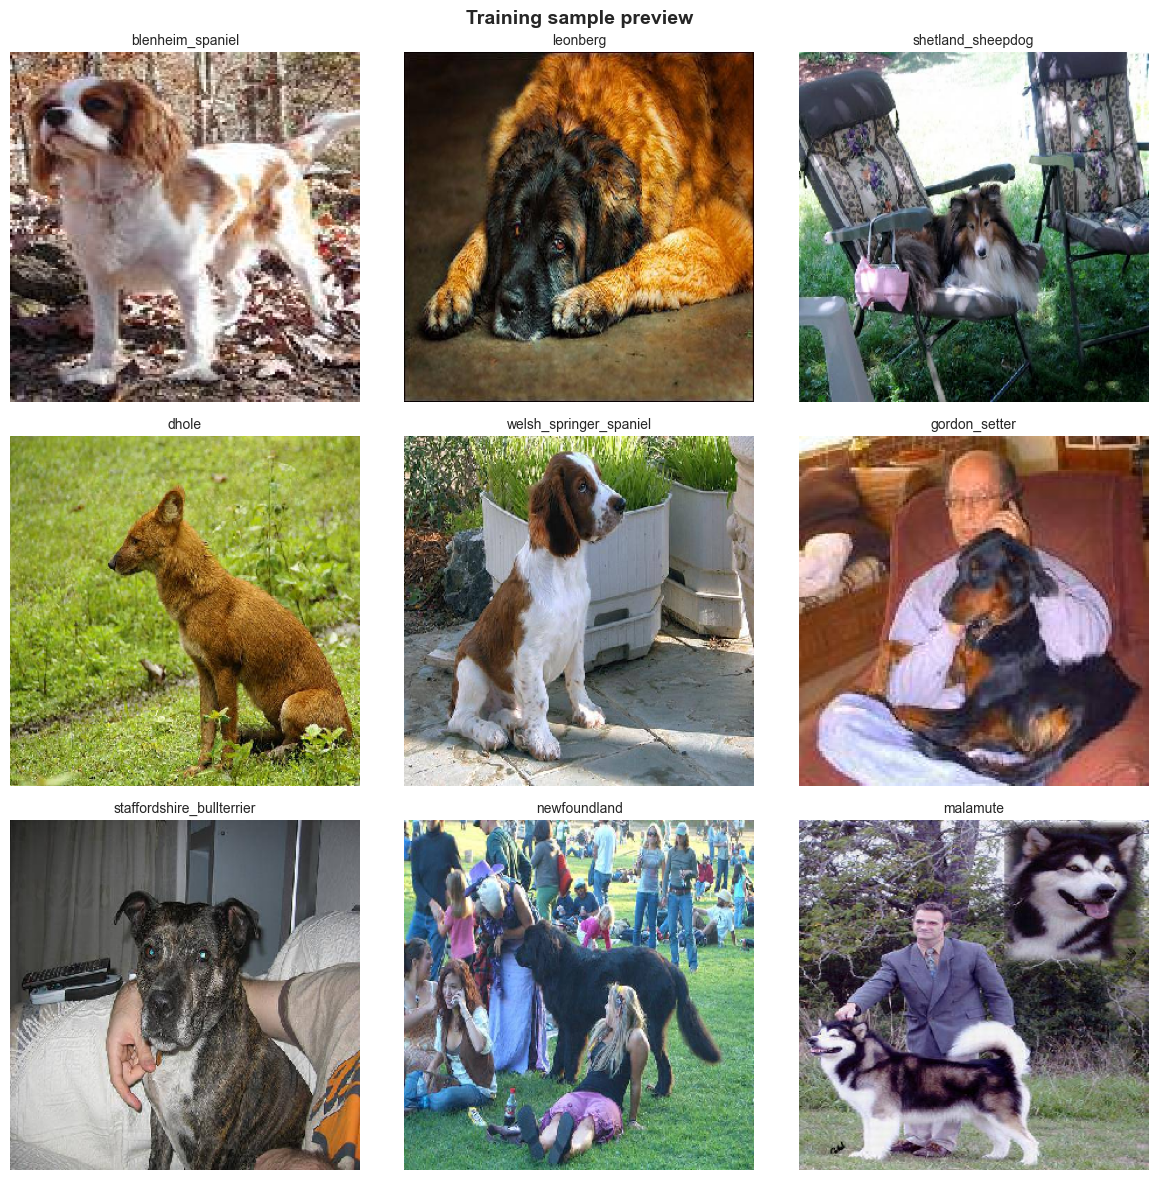

In [3]:
def show_image_grid(frame, title, n=9):
    sample = frame.sample(n=min(n, len(frame)), random_state=SEED).reset_index(drop=True)
    cols = 3
    rows = math.ceil(len(sample) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis('off')
    for ax, (_, row) in zip(axes, sample.iterrows()):
        image = tf.keras.utils.load_img(row['path'], target_size=(IMG_SIZE, IMG_SIZE))
        ax.imshow(image)
        ax.set_title(row['breed'], fontsize=10)
        ax.axis('off')
    fig.suptitle(title, fontsize=14, fontweight='bold')
    fig.tight_layout()

show_image_grid(train_df, 'Training sample preview')

## Input Pipeline

The model receives raw float images through `tf.data`, which keeps the pipeline fast and reproducible.

In [4]:
def load_image(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image_bytes, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE], antialias=True)
    image = tf.cast(image, tf.float32)
    label = tf.one_hot(tf.cast(label, tf.int32), depth=NUM_CLASSES, dtype=tf.float32)
    return image, label


def mixup_batch(images, labels, alpha=MIXUP_ALPHA):
    if alpha <= 0.0:
        return images, labels

    batch_size = tf.shape(images)[0]
    gamma_1 = tf.random.gamma(shape=[batch_size], alpha=alpha)
    gamma_2 = tf.random.gamma(shape=[batch_size], alpha=alpha)
    lam = gamma_1 / (gamma_1 + gamma_2)

    lam_x = tf.reshape(lam, [batch_size, 1, 1, 1])
    lam_y = tf.reshape(lam, [batch_size, 1])

    shuffled_indices = tf.random.shuffle(tf.range(batch_size))
    shuffled_images = tf.gather(images, shuffled_indices)
    shuffled_labels = tf.gather(labels, shuffled_indices)

    mixed_images = lam_x * images + (1.0 - lam_x) * shuffled_images
    mixed_labels = lam_y * labels + (1.0 - lam_y) * shuffled_labels
    return mixed_images, mixed_labels


def make_dataset(frame, training=False):
    paths = frame['path'].astype(str).to_numpy()
    labels = frame['label'].to_numpy(dtype=np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=min(len(frame), 4096), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE, deterministic=not training)
    ds = ds.batch(BATCH_SIZE)

    if training and MIXUP_ALPHA > 0.0:
        ds = ds.map(lambda x, y: mixup_batch(x, y, alpha=MIXUP_ALPHA), num_parallel_calls=AUTOTUNE)

    ds = ds.prefetch(AUTOTUNE)
    options = tf.data.Options()
    options.experimental_deterministic = not training
    return ds.with_options(options)


train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
print(train_ds)
print(val_ds)


<_OptionsDataset element_spec=(TensorSpec(shape=(None, 300, 300, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.float32, name=None))>
<_OptionsDataset element_spec=(TensorSpec(shape=(None, 300, 300, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.float32, name=None))>


## Model Architecture

In [5]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip('horizontal', seed=SEED),
        layers.RandomRotation(0.12, seed=SEED),
        layers.RandomZoom(0.15, seed=SEED),
        layers.RandomContrast(0.15, seed=SEED),
        layers.RandomTranslation(0.08, 0.08, seed=SEED),
    ],
    name='augmentation',
)

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='image_input')
x = data_augmentation(inputs)

base_model = EfficientNetV2S(include_top=False, weights='imagenet')
base_model.trainable = False
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D(name='avg_pool')(x)
x = layers.Dropout(0.40, seed=SEED, name='head_dropout_1')(x)
x = layers.Dense(
    512,
    activation='swish',
    kernel_regularizer=tf.keras.regularizers.l2(1e-5),
    name='dense_projection',
)(x)
x = layers.BatchNormalization(name='projection_bn')(x)
x = layers.Dropout(0.25, seed=SEED, name='head_dropout_2')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32', name='breed_probs')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs, name='dog_breed_efficientnetv2s')
model.summary()


Model: "dog_breed_efficientnetv2s"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)             │ (None, 300, 300, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ augmentation (Sequential)            │ (None, 300, 300, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetv2-s (Functional)        │ (None, 10, 10, 1280)        │      20,331,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ avg_pool (GlobalAveragePooling2D)    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ head_dropout_1 (Dropout)             │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_projection (Dense)             │ (None, 512)                 │         655,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ projection_bn (BatchNormalization)   │ (None, 512)                 │           2,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ head_dropout_2 (Dropout)             │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ breed_probs (Dense)                  │ (None, 120)                 │          61,560 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,050,840 (80.30 MB)

 Trainable params: 718,456 (2.74 MB)

 Non-trainable params: 20,332,384 (77.56 MB)

## Training Stage 1

In [6]:
stage1_callbacks = [
    EarlyStopping(monitor='val_accuracy', mode='max', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=5e-6, verbose=1),
]

model.compile(
    optimizer=AdamW(learning_rate=STAGE1_LR, weight_decay=STAGE1_WEIGHT_DECAY),
    loss=CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=[
        CategoricalAccuracy(name='accuracy'),
        TopKCategoricalAccuracy(k=3, name='top_3_accuracy'),
    ],
)

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE_1_EPOCHS,
    callbacks=stage1_callbacks,
    verbose=1,
)


Epoch 1/12
512/512 ━━━━━━━━━━━━━━━━━━━━ 1213s 2s/step - accuracy: 0.4144 - loss: 3.5184 - top_3_accuracy: 0.5420 - val_accuracy: 0.9165 - val_loss: 1.1404 - val_top_3_accuracy: 0.9858 - learning_rate: 3.0000e-04
Epoch 2/12
512/512 ━━━━━━━━━━━━━━━━━━━━ 1262s 2s/step - accuracy: 0.7449 - loss: 2.2154 - top_3_accuracy: 0.8771 - val_accuracy: 0.9210 - val_loss: 1.1528 - val_top_3_accuracy: 0.9843 - learning_rate: 3.0000e-04
Epoch 3/12
512/512 ━━━━━━━━━━━━━━━━━━━━ 940s 2s/step - accuracy: 0.7624 - loss: 2.1325 - top_3_accuracy: 0.8857 - val_accuracy: 0.9229 - val_loss: 1.1315 - val_top_3_accuracy: 0.9877 - learning_rate: 3.0000e-04
Epoch 4/12
512/512 ━━━━━━━━━━━━━━━━━━━━ 976s 2s/step - accuracy: 0.7775 - loss: 2.0707 - top_3_accuracy: 0.9008 - val_accuracy: 0.9303 - val_loss: 1.1145 - val_top_3_accuracy: 0.9853 - learning_rate: 3.0000e-04
Epoch 5/12
512/512 ━━━━━━━━━━━━━━━━━━━━ 947s 2s/step - accuracy: 0.7824 - loss: 2.0327 - top_3_accuracy: 0.9021 - val_accuracy: 0.9288 - val_loss: 1.1122 

## Training Stage 2

In [7]:
def configure_fine_tuning(backbone, trainable_layers=FINE_TUNE_LAYERS):
    backbone.trainable = True
    trainable_layers = max(0, min(trainable_layers, len(backbone.layers)))
    cutoff = max(0, len(backbone.layers) - trainable_layers)

    for layer in backbone.layers[:cutoff]:
        layer.trainable = False

    for layer in backbone.layers[cutoff:]:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    return cutoff


cutoff_index = configure_fine_tuning(base_model, FINE_TUNE_LAYERS)
print(f'Fine-tuning from layer index {cutoff_index} of {len(base_model.layers)} total layers')

stage2_callbacks = [
    EarlyStopping(monitor='val_accuracy', mode='max', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
]

model.compile(
    optimizer=AdamW(learning_rate=STAGE2_LR, weight_decay=STAGE2_WEIGHT_DECAY),
    loss=CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING / 2.0),
    metrics=[
        CategoricalAccuracy(name='accuracy'),
        TopKCategoricalAccuracy(k=3, name='top_3_accuracy'),
    ],
)

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE_2_EPOCHS,
    callbacks=stage2_callbacks,
    verbose=1,
)


Fine-tuning from layer index 393 of 513 total layers
Epoch 1/12
512/512 ━━━━━━━━━━━━━━━━━━━━ 1165s 2s/step - accuracy: 0.8024 - loss: 1.6664 - top_3_accuracy: 0.9132 - val_accuracy: 0.9313 - val_loss: 0.6933 - val_top_3_accuracy: 0.9892 - learning_rate: 2.0000e-05
Epoch 2/12
512/512 ━━━━━━━━━━━━━━━━━━━━ 1131s 2s/step - accuracy: 0.8146 - loss: 1.6009 - top_3_accuracy: 0.9223 - val_accuracy: 0.9273 - val_loss: 0.7019 - val_top_3_accuracy: 0.9872 - learning_rate: 2.0000e-05
Epoch 3/12
512/512 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8322 - loss: 1.5671 - top_3_accuracy: 0.9298
Epoch 3: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-06.
512/512 ━━━━━━━━━━━━━━━━━━━━ 1123s 2s/step - accuracy: 0.8322 - loss: 1.5671 - top_3_accuracy: 0.9298 - val_accuracy: 0.9264 - val_loss: 0.7043 - val_top_3_accuracy: 0.9897 - learning_rate: 2.0000e-05
Epoch 4/12
512/512 ━━━━━━━━━━━━━━━━━━━━ 1114s 2s/step - accuracy: 0.8358 - loss: 1.5502 - top_3_accuracy: 0.9312 - val_accuracy: 0.9278 

## Evaluation

In [8]:
evaluation = model.evaluate(val_ds, return_dict=True, verbose=1)
evaluation_df = pd.DataFrame([evaluation])
display(evaluation_df)
print('Validation metrics:')
for key, value in evaluation.items():
    print(f'{key}: {value:.4f}')

128/128 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.9284 - loss: 0.7066 - top_3_accuracy: 0.9896


,accuracy,loss,top_3_accuracy
0,0.931271,0.693272,0.9892


Validation metrics:
accuracy: 0.9313
loss: 0.6933
top_3_accuracy: 0.9892


## Training Curves

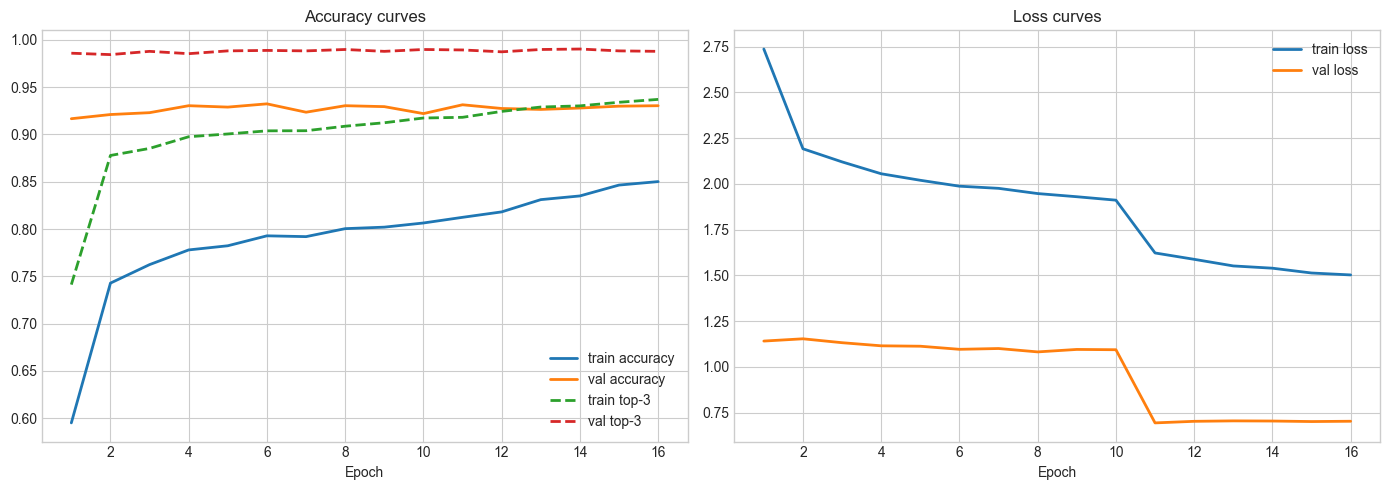

In [9]:
def merge_histories(*histories):
    merged = {}
    for history in histories:
        for key, values in history.history.items():
            merged.setdefault(key, []).extend(values)
    return merged

history = merge_histories(history_stage1, history_stage2)
epochs = range(1, len(history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs, history.get('accuracy', []), label='train accuracy', linewidth=2)
axes[0].plot(epochs, history.get('val_accuracy', []), label='val accuracy', linewidth=2)
axes[0].plot(epochs, history.get('top_3_accuracy', []), label='train top-3', linewidth=2, linestyle='--')
axes[0].plot(epochs, history.get('val_top_3_accuracy', []), label='val top-3', linewidth=2, linestyle='--')
axes[0].set_title('Accuracy curves')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs, history.get('loss', []), label='train loss', linewidth=2)
axes[1].plot(epochs, history.get('val_loss', []), label='val loss', linewidth=2)
axes[1].set_title('Loss curves')
axes[1].set_xlabel('Epoch')
axes[1].legend()

fig.tight_layout()

## Export

In [ ]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SAVED_MODEL_PATH = OUTPUT_DIR / 'saved_model'

with open(INDEX_TO_CLASS_PATH, 'w', encoding='utf-8') as f:
    json.dump(index_to_class, f, indent=2, ensure_ascii=False)

model.save(KERAS_MODEL_PATH)
model.save(LEGACY_H5_PATH)

if SAVED_MODEL_PATH.exists():
    import shutil

    if SAVED_MODEL_PATH.is_dir():
        shutil.rmtree(SAVED_MODEL_PATH)
    else:
        SAVED_MODEL_PATH.unlink()

if hasattr(model, 'export'):
    model.export(SAVED_MODEL_PATH)
else:
    model.save(SAVED_MODEL_PATH, save_format='tf')

export_summary = pd.DataFrame(
    [
        {'artifact': 'Keras model', 'path': str(KERAS_MODEL_PATH), 'exists': KERAS_MODEL_PATH.exists()},
        {'artifact': 'SavedModel', 'path': str(SAVED_MODEL_PATH), 'exists': SAVED_MODEL_PATH.exists()},
        {'artifact': 'Legacy H5', 'path': str(LEGACY_H5_PATH), 'exists': LEGACY_H5_PATH.exists()},
        {'artifact': 'Index mapping', 'path': str(INDEX_TO_CLASS_PATH), 'exists': INDEX_TO_CLASS_PATH.exists()},
    ]
)
display(export_summary)
print('Artifacts exported successfully.')


## Inference Demo

,rank,breed,confidence,confidence_pct
0,1,labrador_retriever,0.961532,96.15
1,2,kelpie,0.003663,0.37
2,3,dingo,0.003465,0.35


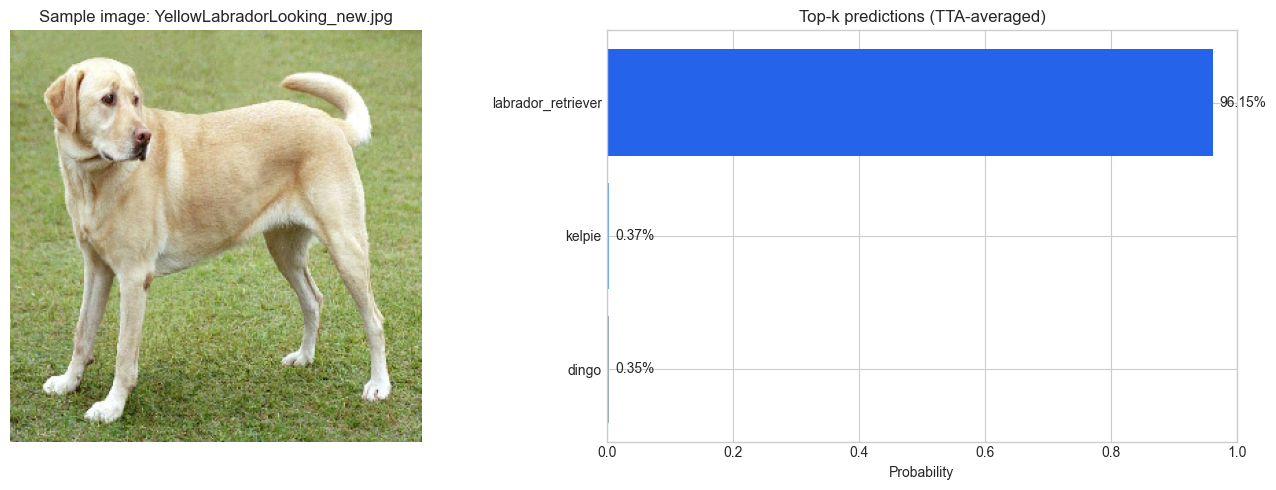

In [11]:
def preprocess_image(image_path):
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f'Image not found: {image_path}')
    image = tf.keras.utils.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE), color_mode='rgb')
    return tf.keras.utils.img_to_array(image, dtype='float32')


def build_tta_batch(image_array, tta_steps=3):
    views = [image_array]
    if tta_steps >= 2:
        views.append(np.fliplr(image_array).copy())
    if tta_steps >= 3:
        crop = tf.image.central_crop(image_array, central_fraction=0.9)
        views.append(tf.image.resize(crop, [IMG_SIZE, IMG_SIZE], antialias=True).numpy())
    return np.stack(views[: max(1, tta_steps)], axis=0).astype('float32')


def predict_image(model, image_path, class_names, top_k=3, tta_steps=3):
    image_array = preprocess_image(image_path)
    batch = build_tta_batch(image_array, tta_steps=tta_steps)
    probabilities = model.predict(batch, verbose=0).mean(axis=0)
    probabilities = probabilities / max(float(probabilities.sum()), 1e-8)

    top_indices = np.argsort(probabilities)[::-1][:top_k]
    results = []
    for rank, class_index in enumerate(top_indices, start=1):
        results.append(
            {
                'rank': rank,
                'breed': class_names[class_index],
                'confidence': float(probabilities[class_index]),
            }
        )
    return pd.DataFrame(results)


if SAMPLE_IMAGE_PATH.exists():
    top_predictions = predict_image(model, SAMPLE_IMAGE_PATH, class_names, top_k=3, tta_steps=3)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sample_image = tf.keras.utils.load_img(SAMPLE_IMAGE_PATH, target_size=(IMG_SIZE, IMG_SIZE))
    axes[0].imshow(sample_image)
    axes[0].set_title(f'Sample image: {SAMPLE_IMAGE_PATH.name}')
    axes[0].axis('off')

    chart = top_predictions.sort_values('confidence', ascending=True)
    axes[1].barh(chart['breed'], chart['confidence'], color=['#94a3b8', '#60a5fa', '#2563eb'])
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel('Probability')
    axes[1].set_title('Top-k predictions (TTA-averaged)')
    for idx, (_, row) in enumerate(chart.iterrows()):
        axes[1].text(row['confidence'] + 0.01, idx, f"{row['confidence']:.2%}", va='center')
    fig.tight_layout()
    display(top_predictions.assign(confidence_pct=lambda frame: (frame['confidence'] * 100).round(2)))
else:
    print(f'Sample image not found: {SAMPLE_IMAGE_PATH}')


## Troubleshooting

- Set `DOG_BREED_PROJECT_ROOT` if the notebook is opened outside the repo root.
- Set `DOG_BREED_DATA_DIR` if the dataset is stored somewhere other than `archive (1)`.
- Reduce `DOG_BREED_BATCH_SIZE` or the stage epoch counts if training is too slow.
- Keep BatchNorm layers frozen during fine-tuning if validation gets unstable.
- Re-run export if you need fresh `models/model.keras`, `my_dog_breed_model.h5`, or `index_to_class.json`.